In [5]:
from myimports import *
from CircleLoss import CircleLoss
import utils as ut

from TripletLossOnlineHNMining import TripletLossOnlineHNMining,OnlineMineingType

ut.login_hf()   #need this because GPU server keeps going down and scripts fail

2024-08-06 17:46:41.245632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-06 17:46:41.260761: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-06 17:46:41.265454: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-06 17:46:41.278917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-06 17:46:42.038162: W tensorflow/compiler/tf2

Token is valid (permission: write).
Your token has been saved in your configured git credential helpers (store).
Your token has been saved to /home/kperkins411/.cache/huggingface/token
Login successful


In [9]:
%matplotlib ipympl


In [10]:
# %matplotlib ipympl
# %matplotlib notebook
def doplt():
    from mpl_toolkits.mplot3d import Axes3D
    # plt.cla()
    # plt.clf()
    # plt.close()
    import matplotlib.pyplot as plt
    # plt.cla()
    # plt.clf()

    # Create a figure and a 3D axis
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the data points
    ax.scatter(pca_embeds_anchor[:, 0], pca_embeds_anchor[:, 1], pca_embeds_anchor[:, 2], label='Anchor')
    ax.scatter(pca_embeds_pos[:, 0], pca_embeds_pos[:, 1], pca_embeds_pos[:, 2], label='Positive')
    ax.scatter(pca_embeds_neg[:, 0], pca_embeds_neg[:, 1], pca_embeds_neg[:, 2], label='Negative')

    # Add annotations for each point
    for i in range(len(pca_embeds_anchor)):
    
        # Add annotations for each point
        ax.text(pca_embeds_anchor[i, 0], pca_embeds_anchor[i, 1], pca_embeds_anchor[i, 2], f'{i}')
        ax.text(pca_embeds_pos[i, 0], pca_embeds_pos[i, 1], pca_embeds_pos[i, 2], f'{i}')
        ax.text(pca_embeds_neg[i, 0], pca_embeds_neg[i, 1], pca_embeds_neg[i, 2], f'{i}')

    # Set labels and legend
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')
    ax.legend()

    # Show the plot
    plt.show()

In [17]:
train_dataset = trn=pd.read_json("../data/trn_with_hard_negatives.json", orient="records",lines=True)[:25]
# train_dataset.loc[0,'anchor']
# train_dataset

In [18]:
# what model are we using
modelname='sentence-transformers/msmarco-distilbert-base-v2'.split('/')[-1]
model = SentenceTransformer('sentence-transformers/msmarco-distilbert-base-v2',trust_remote_code=True,device="cuda:0" if torch.cuda.is_available() else "cpu",)

# model=SentenceTransformer(f"models/msmarco-distilbert-base-v2/CircleLoss/final",device="cuda:0" if torch.cuda.is_available() else "cpu",)
# model = SentenceTransformer(f"models/{modelname}/pos_anchor/final",device="cuda:0" if torch.cuda.is_available() else "cpu",)
# model = SentenceTransformer(f"models/msmarco-distilbert-base-v2/TripletLoss/final",device="cuda:0" if torch.cuda.is_available() else "cpu",)

embeds_anchor=[model.encode([train_dataset['anchor'][i]])[0] for i in range(len(train_dataset))]
embeds_pos=[model.encode([train_dataset['positive'][i]])[0] for i in range(len(train_dataset))]
embeds_neg=[model.encode([train_dataset['negative'][i]])[0] for i in range(len(train_dataset))]

from sklearn.decomposition import PCA

pca_embeds_anchor = PCA(n_components=3).fit_transform(embeds_anchor)
pca_embeds_pos = PCA(n_components=3).fit_transform(embeds_pos)
pca_embeds_neg = PCA(n_components=3).fit_transform(embeds_neg)

/home/kperkins411/anaconda3/envs/p311/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


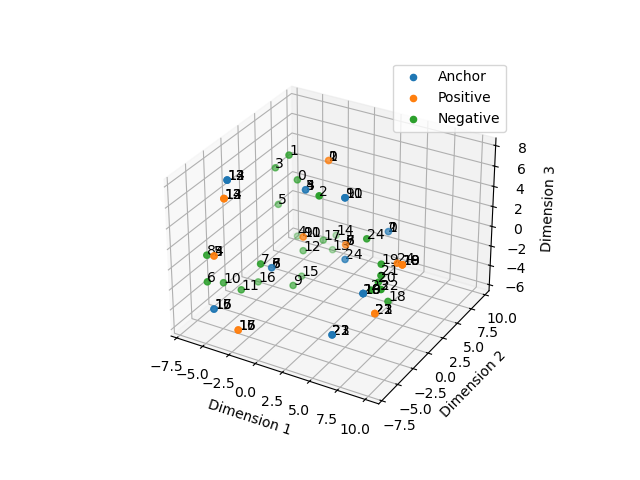

In [19]:
doplt()

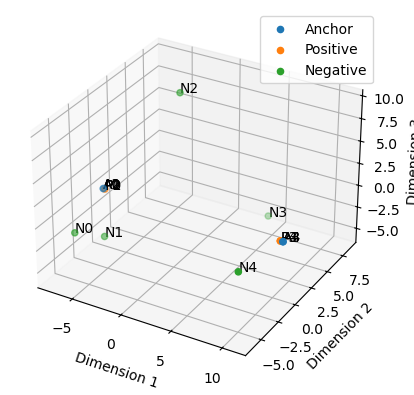

In [24]:
doplt()

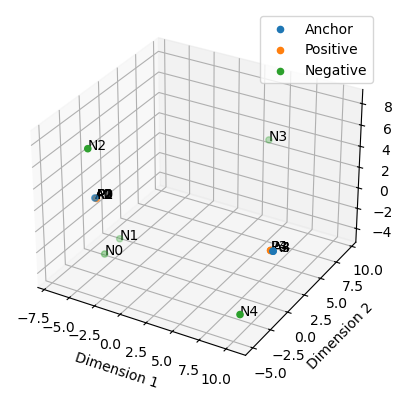

In [14]:
doplt()

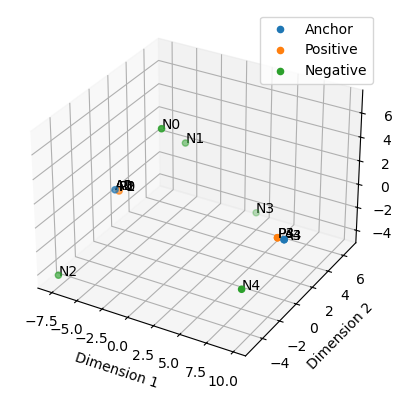

In [16]:
doplt()